In [60]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns

#loading data
dataset=load_dataset('lukebarousse/data_jobs')

#converting the loaded dataset into a pandas dataframe
df=dataset['train'].to_pandas()

#formatting datetime
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

#cleaning the job_skills column by converting them from strings into lists
import ast
df['job_skills']=df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills )

In [44]:
#filtering out jobs in the united states and exploding the skills column
df_us=df[df['job_country']=='United States']
df_exploded=df_us.explode('job_skills')

In [45]:
#grouping by skills and job titles
df_skills=df_exploded.groupby(['job_skills', 'job_title_short']).size()
df_skills=df_skills.reset_index(name='skill_count')
df_skills=df_skills.sort_values(by='skill_count', ascending=False)

In [47]:
#creating a dataframe that provides the count for each job
df_jobs=df_us['job_title_short'].value_counts().reset_index(name='job_count')

In [55]:
#merging the 2 dataframes and creating the skill percent column
df_new=pd.merge(df_skills, df_jobs, how='left', on='job_title_short')
df_new['skill_percent']= 100* df_new['skill_count']/df_new['job_count']

In [56]:
df_new

,job_skills,job_title_short,skill_count,job_count,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,clojure,Software Engineer,1,1814,0.055127
1866,vb.net,Senior Data Scientist,1,12946,0.007724
1867,fortran,Machine Learning Engineer,1,921,0.108578
1868,planner,Cloud Engineer,1,423,0.236407


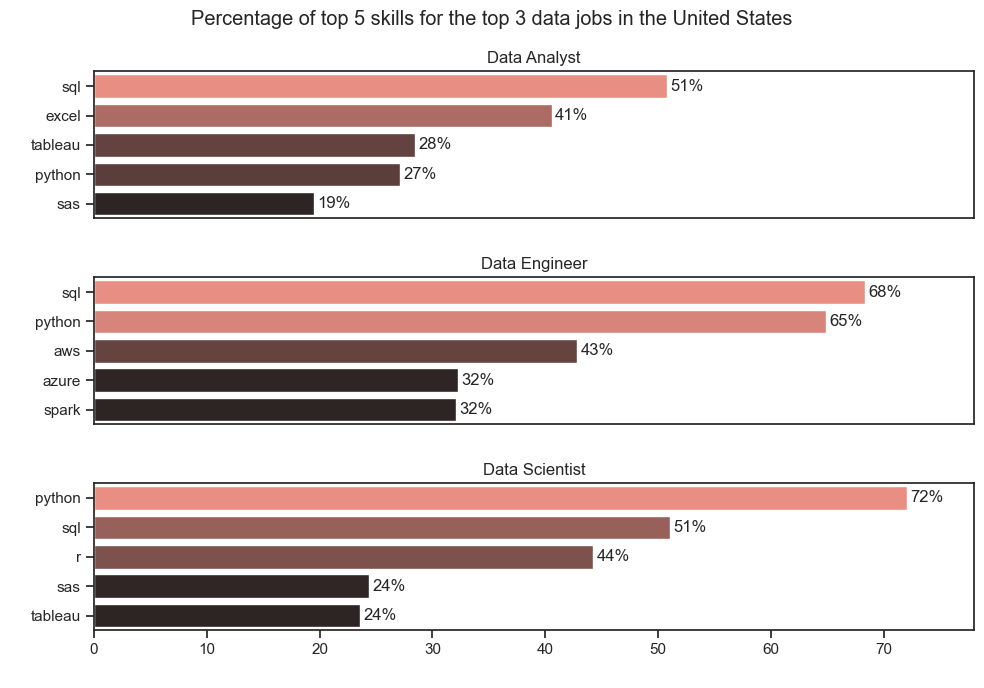

In [99]:
#plotting a bar plot that shows the skill demand for the top 3 data jobs
jobs=['Data Analyst', 'Data Engineer', 'Data Scientist']
fig,ax=plt.subplots(3,1, figsize=(10,7))
sns.set_theme(style='ticks')
for i, job in enumerate(jobs):
    df_plot=df_new[df_new['job_title_short']==job].head(5)
    sns.barplot(df_plot, x='skill_percent', y='job_skills',ax=ax[i], hue='skill_percent', palette='dark:salmon', legend=False)
    ax[i].set_title(job)
    ax[i].set_ylabel(' ')
    ax[i].set_xlabel(' ')
    ax[i].set_xlim(0,78)
    for n, txt in enumerate(df_plot['skill_percent']):
        ax[i].text(txt+0.3, n, f'{txt:.0f}%', va='center')
    
    if i != len(jobs)-1:
        ax[i].set_xticks([])
       

plt.suptitle('Percentage of top 5 skills for the top 3 data jobs in the United States')
plt.tight_layout()
plt.show()


